In [1]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [3]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")

In [5]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [7]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [8]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [9]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [10]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [11]:
emission_fields.remove(target_var)
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [12]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [13]:
redoundant_fields = [
    # "cap_gdp_per_capita_ppp_current",
    "con_population"
]

In [14]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Check for correlation between features

In [15]:
X = df_filtered.drop(columns=["iso_alpha_3", "year", target_var])

In [16]:
def get_corr_pairs_df(df, corr_thr=0.9):

    features_corr = df.corr().abs()
    pairs = []

    for i in range(len(features_corr.columns)):
        for j in range(i+1, len(features_corr.columns)):
            if abs(features_corr.iloc[i, j]) > corr_thr:
                pairs.append(
                    (features_corr.columns[i],
                    features_corr.columns[j],
                    features_corr.iloc[i, j])
                )

    pairs_df = pd.DataFrame(pairs, columns=["feat_1","feat_2","corr"])
    return pairs_df

In [17]:
# Here we set a stricter corr thr
pairs_df = get_corr_pairs_df(X, corr_thr=0.95)
pairs_df.head()

,feat_1,feat_2,corr
0,cap_electoral_democracy_idx,cap_liberal_democracy_idx,0.976441
1,cap_electoral_democracy_idx,cap_accountability_idx,0.955689
2,cap_liberal_democracy_idx,cap_voice_accountability,0.952185
3,cap_control_corruption,cap_rule_of_law,0.953423
4,cap_govt_effectiveness,cap_rule_of_law,0.957012


In [18]:
pairs_df.to_clipboard(index=False)

In [19]:

# print(f"Dropping {len(to_drop)} variables")
# print("Shape before dropping: ", df_filtered.shape)
# df_filtered = df_filtered.drop(columns=to_drop)
# print("Shape after dropping: ", df_filtered.shape)


In [20]:
# X = df_filtered.drop(columns=["iso_alpha_3", "year", target_var])
# pairs_df_after_drop = get_corr_pairs_df(X)
# pairs_df_after_drop

### Fix Skewness

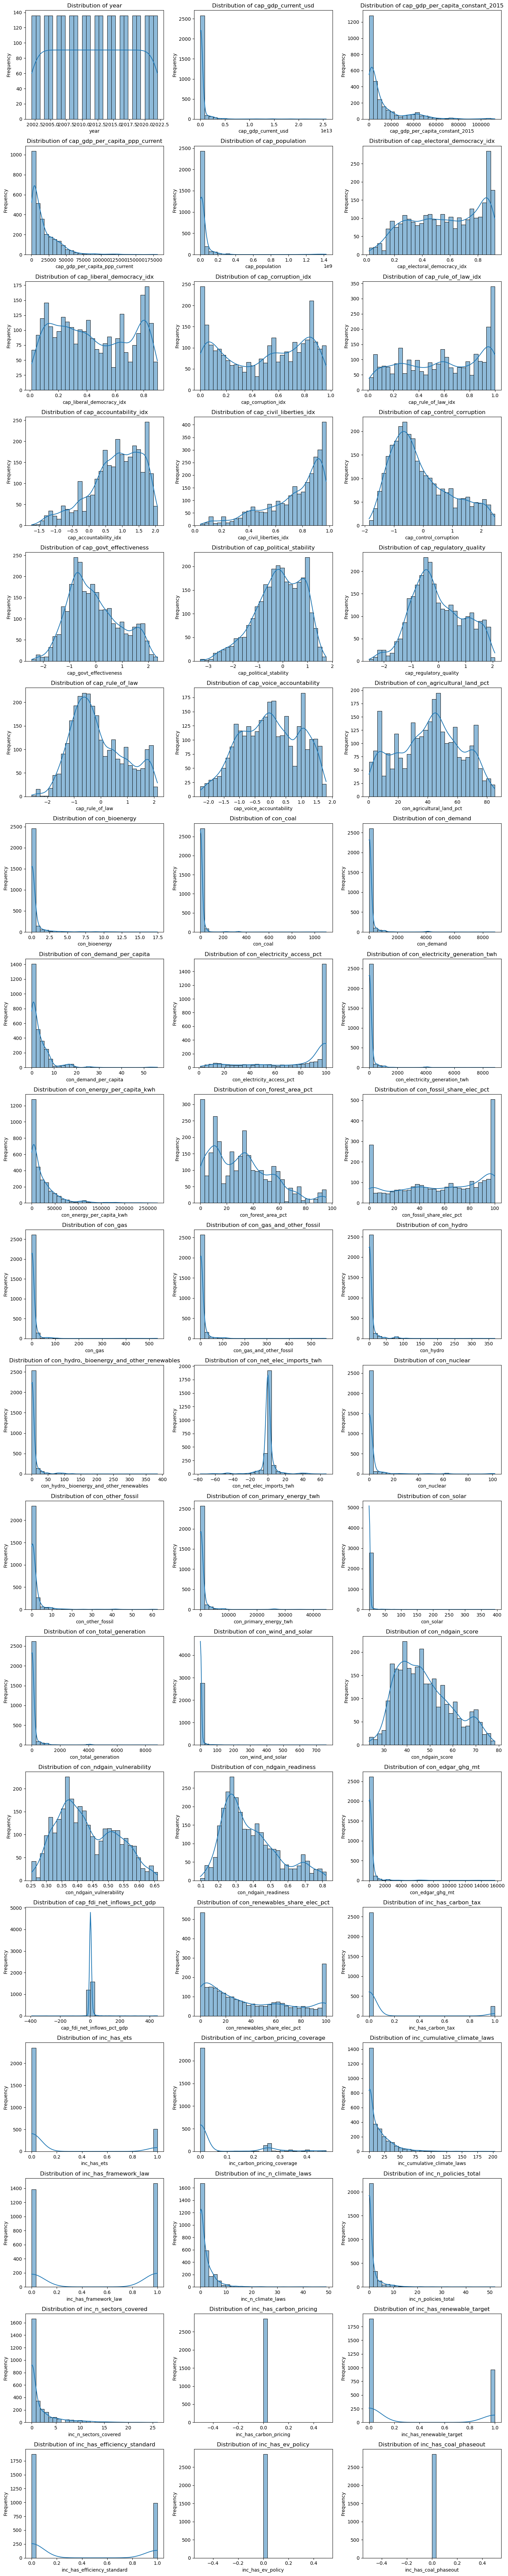

In [21]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [22]:
df_filtered.describe()

,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_accountability_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
count,2856.000000,2.856000e+03,2856.000000,2856.000000,2.856000e+03,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0
mean,2012.000000,4.549098e+11,12569.581328,17825.876908,4.474379e+07,0.566125,0.447432,0.487975,0.575038,0.801282,...,14.716737,0.515406,2.184174,1.440476,1.761204,0.0,0.337535,0.345588,0.0,0.0
std,6.056361,1.823163e+12,17858.950458,20297.376882,1.618958e+08,0.247124,0.262918,0.313468,0.308789,0.789647,...,21.349578,0.499850,3.496865,3.233141,3.296187,0.0,0.472952,0.475643,0.0,0.0
min,2002.000000,8.517107e+07,243.076666,492.840755,8.247500e+04,0.019000,0.012000,0.002000,0.010000,-1.725000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
25%,2007.000000,1.017460e+10,1380.254844,3590.244442,3.263544e+06,0.353000,0.217000,0.170000,0.300500,0.356500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
50%,2012.000000,3.302481e+10,4789.834002,10813.936025,9.695688e+06,0.582000,0.421000,0.532000,0.592500,0.899000,...,7.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
75%,2017.000000,1.894862e+11,15053.013707,25802.122340,2.838703e+07,0.801000,0.688000,0.784000,0.871000,1.429250,...,22.000000,1.000000,3.000000,1.000000,2.000000,0.0,1.000000,1.000000,0.0,0.0
max,2022.000000,2.560485e+13,112417.876989,180939.439450,1.425423e+09,0.923000,0.897000,0.965000,0.999000,2.056000,...,203.000000,1.000000,49.000000,52.000000,26.000000,0.0,1.000000,1.000000,0.0,0.0


In [23]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [24]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [25]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [26]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [27]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [28]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                                    18.100333
con_wind_and_solar                           16.703063
con_coal                                     10.716587
con_gas                                      10.058157
con_gas_and_other_fossil                      9.636615
con_hydro                                     8.669590
cap_fdi_net_inflows_pct_gdp                   8.480725
con_edgar_ghg_mt                              8.467774
con_total_generation                          8.356955
con_electricity_generation_twh                8.356955
con_demand                                    8.351667
con_hydro,_bioenergy_and_other_renewables     8.346573
cap_gdp_current_usd                           8.097445
con_primary_energy_twh                        7.524785
cap_population                                7.233621
con_nuclear                                   6.399152
con_other_fossil                              6.160889
con_bioenergy                                 5.676543
inc_n_poli

In [29]:
skew.tail(10)

cap_voice_accountability      -0.111544
cap_corruption_idx            -0.148069
cap_rule_of_law_idx           -0.172612
cap_electoral_democracy_idx   -0.224062
con_fossil_share_elec_pct     -0.295079
cap_political_stability       -0.516479
cap_accountability_idx        -0.708478
con_net_elec_imports_twh      -0.981781
cap_civil_liberties_idx       -1.038481
con_electricity_access_pct    -1.156544
dtype: float64

In [30]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_gas',
 'con_gas_and_other_fossil',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'con_total_generation',
 'con_electricity_generation_twh',
 'con_demand',
 'con_hydro,_bioenergy_and_other_renewables',
 'cap_gdp_current_usd',
 'con_primary_energy_twh',
 'cap_population',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'inc_n_policies_total',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'inc_n_sectors_covered',
 'cap_gdp_per_capita_ppp_current',
 'cap_gdp_per_capita_constant_2015',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

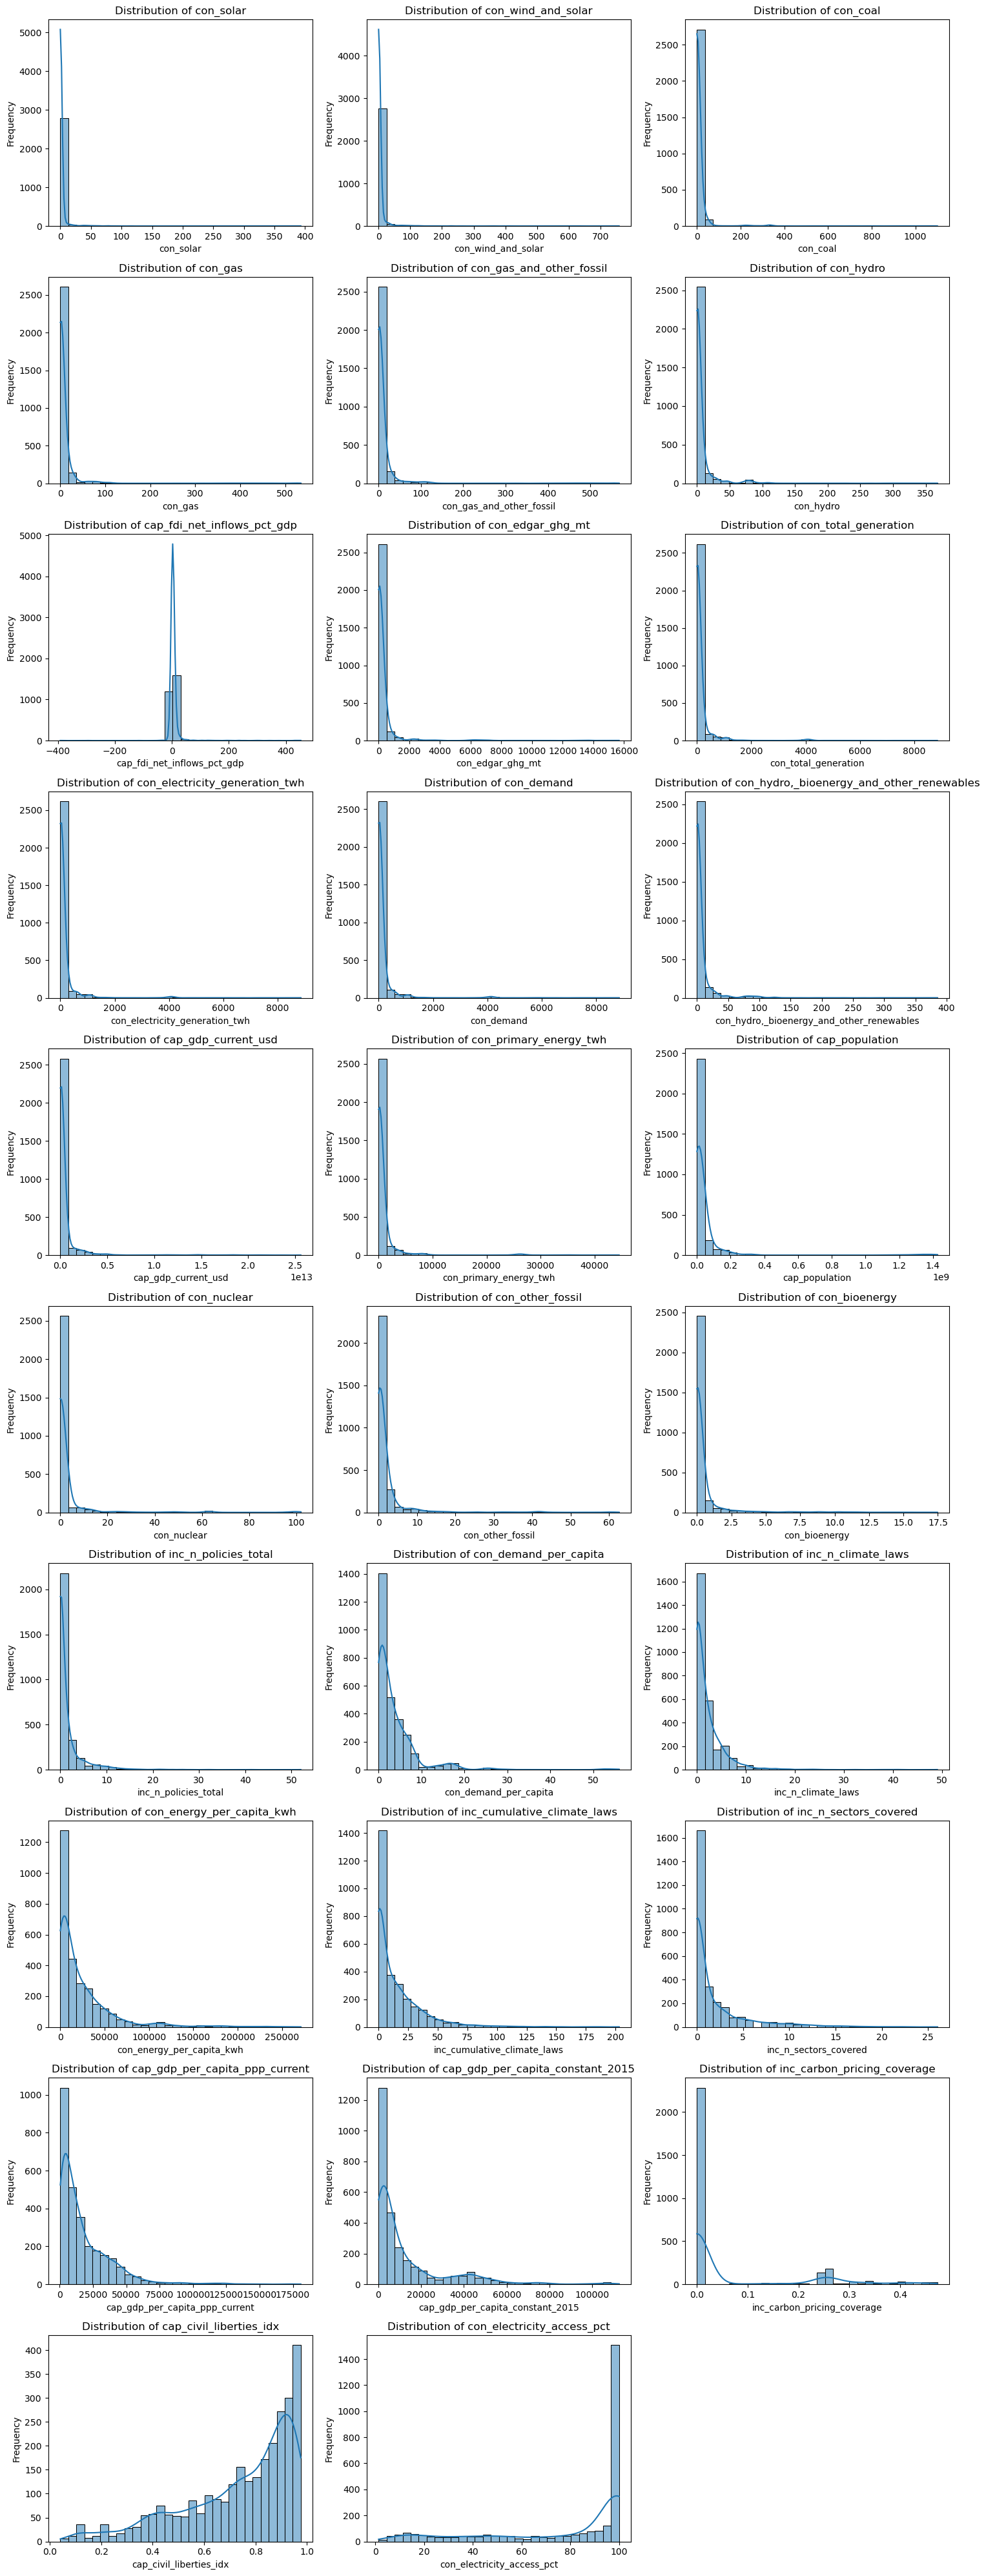

In [31]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

In [32]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,...,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,0.137,...,0.039221,0.0,5.054301,0.0,0.0,6.832501,5.826413,0.0,0.420682,2.714695
1,AFG,2003,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,0.129,...,0.039221,0.0,5.167969,0.0,0.0,6.875193,5.849531,0.0,0.438255,2.995732
2,AFG,2004,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,0.123,...,0.039221,0.0,5.067381,0.0,0.0,6.880007,5.827878,0.0,0.435671,3.210844
3,AFG,2005,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,0.117,...,0.039221,0.0,5.330145,0.0,0.0,6.982016,5.898911,0.0,0.433080,3.391147
4,AFG,2006,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,0.116,...,0.048790,0.0,5.552444,0.0,0.0,7.023612,5.910141,0.0,0.431782,3.540959


In [33]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 84 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   iso_alpha_3                                             2856 non-null   object 
 1   year                                                    2856 non-null   int64  
 2   cap_gdp_current_usd                                     2856 non-null   float64
 3   cap_gdp_per_capita_constant_2015                        2856 non-null   float64
 4   cap_gdp_per_capita_ppp_current                          2856 non-null   float64
 5   cap_population                                          2856 non-null   float64
 6   cap_electoral_democracy_idx                             2856 non-null   float64
 7   cap_liberal_democracy_idx                               2856 non-null   float64
 8   cap_corruption_idx                    

In [34]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [35]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_solar                                    4.072531
x_log_signed_con_bioenergy                                3.204910
x_log_signed_con_wind_and_solar                           2.861822
x_log_signed_con_nuclear                                  2.769048
x_log_signed_con_coal                                     2.328500
x_log_signed_con_other_fossil                             1.994020
x_log_signed_inc_carbon_pricing_coverage                  1.766301
x_log_signed_con_hydro                                    1.589147
x_log_signed_con_hydro,_bioenergy_and_other_renewables    1.547016
x_log_signed_con_gas                                      1.486547
x_log_signed_inc_n_policies_total                         1.402111
x_log_signed_con_gas_and_other_fossil                     1.395439
x_log_signed_inc_n_sectors_covered                        1.126905
con_ndgain_readiness                                      0.853076
cap_control_corruption                                    0.71

In [36]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.679510,False
1,cap_electoral_democracy_idx,0.0,0.061070,False
2,cap_liberal_democracy_idx,0.0,0.069126,False
3,cap_corruption_idx,0.0,0.098262,False
4,cap_rule_of_law_idx,0.0,0.095350,False


In [37]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

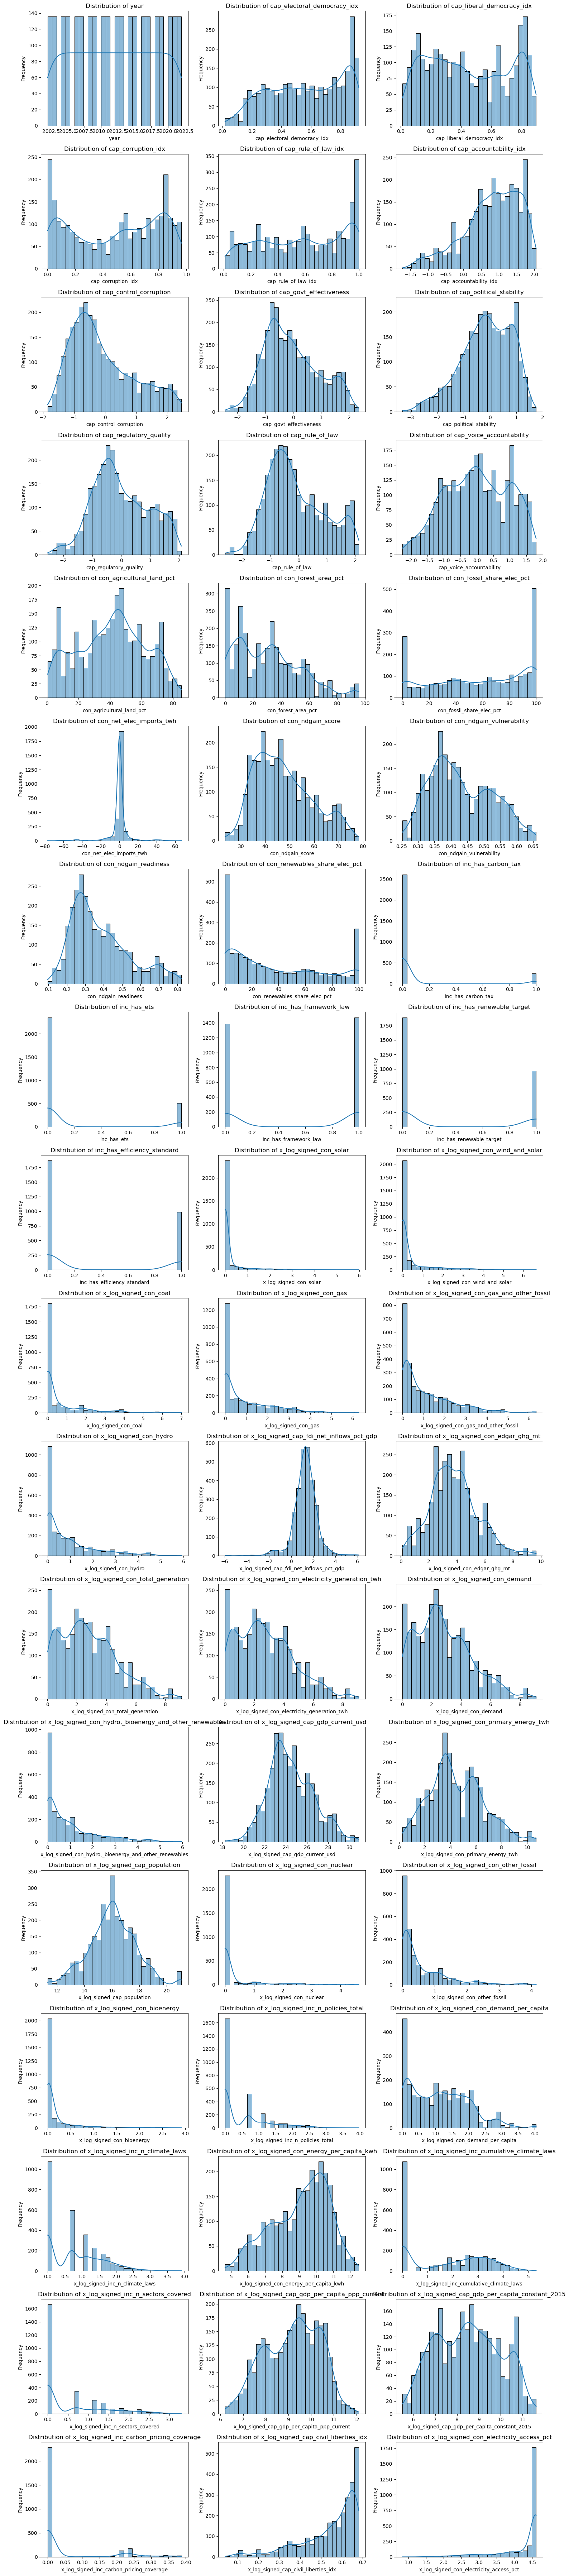

In [38]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [39]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_control_corruption', 'cap_govt_effectiveness',
       'cap_political_stability', 'cap_regulatory_quality', 'cap_rule_of_law',
       'cap_voice_accountability', 'con_agricultural_land_pct',
       'con_forest_area_pct', 'con_fossil_share_elec_pct',
       'con_net_elec_imports_twh', 'con_ndgain_score',
       'con_ndgain_vulnerability', 'con_ndgain_readiness',
       'con_renewables_share_elec_pct', 'inc_has_carbon_tax', 'inc_has_ets',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_gas', 'x_log_signed_con_gas_and_other_fossil',
       'x_log_signed_con_hydro', 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_edgar_gh

## ML

In [40]:
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_accountability_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,0.220,0.084,0.919,0.137,0.227,-1.251137,-1.587687,-2.035034,...,0.039221,0.0,5.054301,0.0,0.0,6.832501,5.826413,0.0,0.420682,2.714695
1,AFG,2003,0.227,0.086,0.919,0.129,0.261,-1.344180,-1.175768,-2.198372,...,0.039221,0.0,5.167969,0.0,0.0,6.875193,5.849531,0.0,0.438255,2.995732
2,AFG,2004,0.238,0.091,0.931,0.123,0.309,-1.350647,-0.945146,-2.295682,...,0.039221,0.0,5.067381,0.0,0.0,6.880007,5.827878,0.0,0.435671,3.210844
3,AFG,2005,0.319,0.113,0.942,0.117,0.372,-1.447252,-1.228816,-2.067510,...,0.039221,0.0,5.330145,0.0,0.0,6.982016,5.898911,0.0,0.433080,3.391147
4,AFG,2006,0.373,0.199,0.955,0.116,0.375,-1.446292,-1.473652,-2.219135,...,0.048790,0.0,5.552444,0.0,0.0,7.023612,5.910141,0.0,0.431782,3.540959


In [41]:
training_df.year.max()

np.int64(2022)

In [42]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [43]:
features = [col for col in training_df.columns if col not in ["iso_alpha_3", "year", target_var]]
features

['cap_electoral_democracy_idx',
 'cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_accountability_idx',
 'cap_control_corruption',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_voice_accountability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_ndgain_readiness',
 'con_renewables_share_elec_pct',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'x_log_signed_con_solar',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_gas_and_other_fossil',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_total_generation',
 'x_log_signed_con_electricity_generation_twh',
 'x_log_signed_con_demand',
 'x_log_signed_c

In [44]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    xgb_params=xgb_params,
    scaler_type="standard",
    feature_cols=features,
    include_year=False
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.2985          nan
RandomForest          0.4081       0.3772
XGBoost               0.3501       0.3614
Median                1.3262       1.3492

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1522         0.1648            0.1842            0.2124               28.83               32.52
RandomForest            0.0170         0.1308            0.0300            0.1923                3.72               41.89
XGBoost                 0.0144         0.1216            0.0195            0.1715                3.26               47.59
Median                  1.3413         1.3160            1.7277            1.7185

{'ElasticNet': {'train_mae_log': 0.15222931126230352,
  'test_mae_log': 0.164804366994514,
  'train_rmse_log': 0.18418580925530675,
  'test_rmse_log': 0.21239184960795807,
  'train_mae_level': np.float64(28.83175635389091),
  'test_mae_level': np.float64(32.51800912458403)},
 'RandomForest': {'train_mae_log': 0.016975496376805163,
  'test_mae_log': 0.1307767823793311,
  'train_rmse_log': 0.029954527783066065,
  'test_rmse_log': 0.1923303632316329,
  'train_mae_level': np.float64(3.718060265580629),
  'test_mae_level': np.float64(41.88644394526231)},
 'XGBoost': {'train_mae_log': 0.0144043343088378,
  'test_mae_log': 0.12164595992550019,
  'train_rmse_log': 0.0194916936154898,
  'test_rmse_log': 0.17147422887326658,
  'train_mae_level': np.float64(3.264291703667542),
  'test_mae_level': np.float64(47.58554310163996)},
 'Median': {'train_mae_log': 1.3413164445990429,
  'test_mae_log': 1.3160106748006133,
  'train_rmse_log': 1.7277404471730828,
  'test_rmse_log': 1.7185362433467504,
  'tr

In [45]:
country_erros_best_preds = ra.per_country_errors(model="ElasticNet")
country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(10)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
11,CHN,5,0.043539,0.047232,632.029229
51,USA,5,0.105768,0.108251,605.201187
67,IND,5,0.138631,0.139742,555.914286
90,BRA,5,0.188975,0.189254,223.619115
32,RUS,5,0.080827,0.112168,223.257984
45,JPN,5,0.096621,0.101242,121.586661
83,TUR,5,0.171714,0.172094,118.795020
105,ZAF,5,0.219510,0.223703,113.223396
73,CAN,5,0.149121,0.150437,104.708081
124,BGD,5,0.315942,0.325682,104.325809


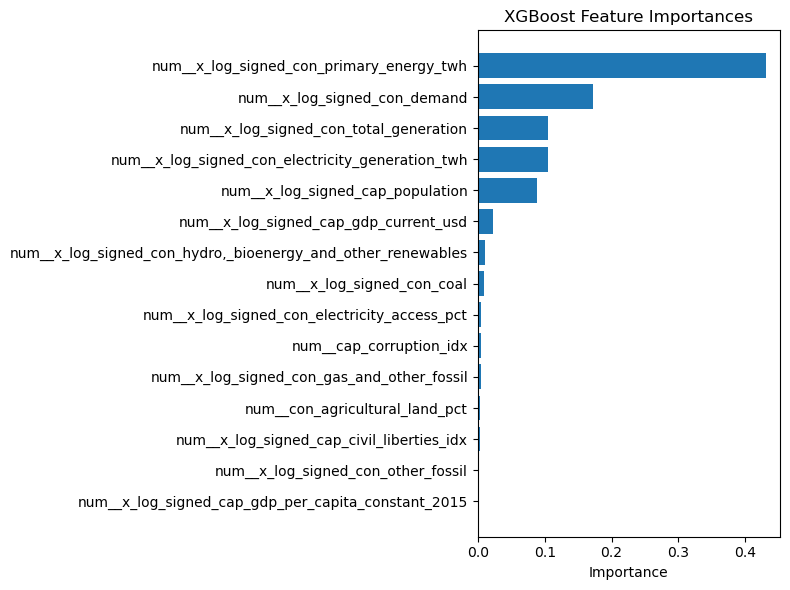

In [46]:
ra.plot_feature_importances(model="XGboost", top_n=15)

In [47]:
def get_coef_table(ml_pipe):

    feature_names = ml_pipe[:-1].get_feature_names_out()

    coefs = ml_pipe.named_steps["enet"].coef_

    coef_table = (
        pd.DataFrame({
            "feature": feature_names,
            "coef": coefs,
            "abs_coef": abs(coefs)
        })
        .sort_values("abs_coef", ascending=False)
    ) 

    coef_table["type"] = coef_table["feature"].apply(lambda x: x.split("_")[0])
    coef_table["clean_feature_name"] = coef_table["feature"].apply(lambda x: "_".join(x.split("_")[2:])) 
    coef_table = coef_table[[
        "clean_feature_name",
        "coef",
        "abs_coef",
        "type"
    ]]
    
    return coef_table

In [48]:
ra_coef_table = get_coef_table(ra.pipe_enet)
ra_coef_table.head()

,clean_feature_name,coef,abs_coef,type
37,x_log_signed_cap_population,0.951464,0.951464,num
36,x_log_signed_con_primary_energy_twh,0.950084,0.950084,num
135,iso_alpha_3_MNG,0.781396,0.781396,cat
181,iso_alpha_3_URY,0.711150,0.711150,cat
153,iso_alpha_3_PNG,-0.666586,0.666586,cat


In [49]:
ra_coef_table.to_clipboard(index=False)

### Train with fewer features

In [68]:
to_drop = [
    "cap_electoral_democracy_idx",
    "cap_accountability_idx",
    "x_log_signed_con_electricity_generation_twh",
    "x_log_signed_con_total_generation",
    "x_log_signed_con_gas_and_other_fossil",
    "x_log_signed_con_hydro,_bioenergy_and_other_renewables",
    "con_ndgain_readiness"
]

In [69]:
# Remove repeated features and also the ones with coefficient 0
redoundant_features = [
    "x_log_signed_cap_gdp_per_capita_constant_2015",
    "x_log_signed_cap_population",
    "x_log_signed_cap_gdp_current_usd"
]

# features_to_remove = to_drop #+ redoundant_features
features_to_remove = redoundant_features #+ to_drop

In [70]:
training_df_filtered = training_df.drop(columns=features_to_remove)

In [71]:
features = [col for col in training_df_filtered.columns if col not in ["iso_alpha_3", "year", target_var]]
features

['cap_electoral_democracy_idx',
 'cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_accountability_idx',
 'cap_control_corruption',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_voice_accountability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_ndgain_readiness',
 'con_renewables_share_elec_pct',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'x_log_signed_con_solar',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_gas_and_other_fossil',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_total_generation',
 'x_log_signed_con_electricity_generation_twh',
 'x_log_signed_con_demand',
 'x_log_signed_c

In [76]:
print("Running regression without group feature...")

enet_params = dict(
    l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    n_alphas=200,          # wider alpha search
    eps=1e-3,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=-1,
    random_state=42,
)

ra_2 = RegressionAnalysis(
    df=training_df_filtered,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    xgb_params=xgb_params,
    scaler_type="standard",
    feature_cols=features,
    include_year=False,
    enet_params=enet_params
)

ra_2.cross_validate()
ra_2.fit()
ra_2.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

ElasticNet            0.2830          nan
RandomForest          0.4879       0.4113
XGBoost               0.4451       0.3959
Median                1.3262       1.3492


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1433         0.1576            0.1753            0.2037               28.78               32.40
RandomForest            0.0198         0.1402            0.0360            0.2091                3.94               38.81
XGBoost                 0.0148         0.1276            0.0206            0.1886                3.54               55.13
Median                  1.3413         1.3160            1.7277            1.7185              265.93              302.69


{'ElasticNet': {'train_mae_log': 0.1432760497027121,
  'test_mae_log': 0.15760742420805318,
  'train_rmse_log': 0.17526220060190878,
  'test_rmse_log': 0.20369458166290397,
  'train_mae_level': np.float64(28.779465390642077),
  'test_mae_level': np.float64(32.398971011456155)},
 'RandomForest': {'train_mae_log': 0.019801587969111422,
  'test_mae_log': 0.14017883414348623,
  'train_rmse_log': 0.036015085166481116,
  'test_rmse_log': 0.209141575591981,
  'train_mae_level': np.float64(3.9449506514489316),
  'test_mae_level': np.float64(38.80697913687688)},
 'XGBoost': {'train_mae_log': 0.014807923670928558,
  'test_mae_log': 0.12757865436597168,
  'train_rmse_log': 0.0205872257861565,
  'test_rmse_log': 0.18859340152405432,
  'train_mae_level': np.float64(3.5380003616910787),
  'test_mae_level': np.float64(55.1256576735298)},
 'Median': {'train_mae_log': 1.3413164445990429,
  'test_mae_log': 1.3160106748006133,
  'train_rmse_log': 1.7277404471730828,
  'test_rmse_log': 1.7185362433467504,

In [73]:
ra_2_coef_table = get_coef_table(ra_2.pipe_enet)
ra_2_coef_table.head()

,clean_feature_name,coef,abs_coef,type
35,x_log_signed_con_primary_energy_twh,2.294607,2.294607,num
42,x_log_signed_con_energy_per_capita_kwh,-0.927994,0.927994,num
132,iso_alpha_3_MNG,0.836972,0.836972,cat
178,iso_alpha_3_URY,0.785818,0.785818,cat
150,iso_alpha_3_PNG,-0.666387,0.666387,cat


In [74]:
ra_2_coef_table.to_clipboard()

In [75]:
country_erros_best_preds = ra_2.per_country_errors(model="ElasticNet")
country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(10)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
15,CHN,5,0.046821,0.050328,678.674670
47,USA,5,0.095658,0.098822,550.153474
64,IND,5,0.135794,0.137013,544.477658
31,RUS,5,0.076991,0.100848,209.715036
77,BRA,5,0.156585,0.157172,188.187966
92,TUR,5,0.186680,0.187227,129.895169
48,JPN,5,0.098772,0.102054,124.464510
99,ZAF,5,0.202666,0.207044,105.431103
101,ITA,5,0.211124,0.213013,93.018370
125,PHL,5,0.310040,0.310136,92.140704


### Notes
- The model performs slightly better when removing the gpd, population and 2015 gdppc. The ppp gdppc is enough.
- Model performance get's worse if we remove highly correlated features, is better to keep them.
- Next step is to use PCA to get better insights of the potential groups and also see if prediction metrics get better when using PCA.